# Instructor Effectiveness Modeling
**Role:** Data Science / AI Content Specialist Intern  

## Step 0 — Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

df = pd.read_csv("instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (2000, 12)


,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


---
## Step 1 — Exploratory Data Analysis (EDA)

In [2]:
# Basic info and missing values
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nSummary stats:")
df.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB
None

Missing values:
batch_id           

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,0.60,27.04,77.96,0.39,0.78,0.75,0.25,4.21,0.74
std,0.16,5.72,10.70,0.16,0.15,0.15,0.10,0.42,0.15
min,0.30,6.16,40.39,0.02,0.29,0.25,0.00,2.64,0.26
25%,0.49,23.12,70.90,0.28,0.68,0.65,0.18,3.92,0.63
50%,0.60,26.94,78.02,0.39,0.78,0.76,0.25,4.21,0.74
75%,0.71,30.89,85.44,0.51,0.89,0.86,0.32,4.50,0.85
max,0.98,40.00,100.00,0.70,1.00,1.00,0.64,5.00,1.00


In [3]:
print(f"Unique instructors : {df['instructor_id'].nunique()}")
print(f"Unique courses     : {df['course_id'].nunique()}")
print(f"Avg batches per instructor: {df.groupby('instructor_id')['batch_id'].count().mean():.1f}")

Unique instructors : 120
Unique courses     : 25
Avg batches per instructor: 16.7


In [4]:
# key features
feature_cols = [
    "completion_rate", "dropout_rate", "avg_score_improvement",
    "avg_quiz_score", "avg_watch_time", "assignment_submission_rate",
    "forum_activity_rate", "avg_feedback_score", "feedback_response_rate"
]

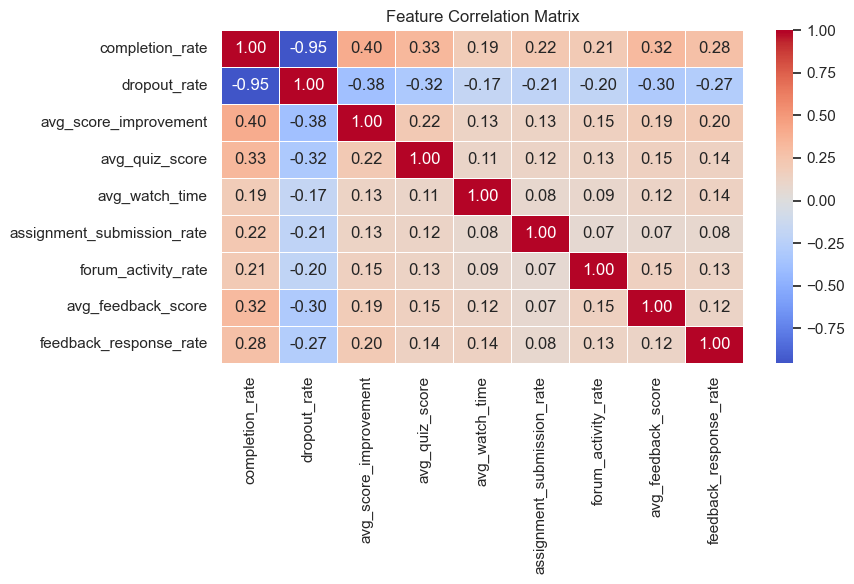

In [5]:
# Correlation heatmap
corr = df[feature_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

### Observations
- No missing values found.
- `completion_rate` and `dropout_rate` are strongly negatively correlated — expected, they are near-complements.

---
## Step 2 — Define Instructor Effectiveness

An effective instructor should retain learners, improve their scores, keep them engaged, and earn good feedback. We build a weighted composite score from four components:

| Component | Features | Weight |
|---|---|---|
| Retention | completion_rate, dropout_rate | 30% |
| Outcomes | avg_score_improvement, avg_quiz_score | 30% |
| Engagement | avg_watch_time, assignment_submission_rate, forum_activity_rate | 25% |
| Feedback | avg_feedback_score (scaled), feedback_response_rate | 15% |

Retention and outcomes carry the most weight since they reflect the core mission of the course. Feedback is weighted lower because it can be biased. We adjust feedback by response rate to penalise scores based on very few submissions.

Tiers are assigned using **tertiles** (Low / Medium / High) so classes stay balanced.

In [6]:
df2 = df.copy()

# Normalise non 0-1 columns to 0-1
def minmax(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

df2["score_imp_norm"] = minmax(df2["avg_score_improvement"])
df2["quiz_norm"]      = minmax(df2["avg_quiz_score"])
df2["feedback_norm"]  = (df2["avg_feedback_score"] - 1) / 4

# Four components
df2["retention"]  = df2["completion_rate"] * 0.6 + (1 - df2["dropout_rate"]) * 0.4
df2["outcomes"]   = df2["score_imp_norm"] * 0.5 + df2["quiz_norm"] * 0.5
df2["engagement"] = (df2["avg_watch_time"] * 0.35 +
                     df2["assignment_submission_rate"] * 0.40 +
                     df2["forum_activity_rate"] * 0.25)
df2["feedback"]   = df2["feedback_norm"] * df2["feedback_response_rate"]

# Final composite score
df2["effectiveness_score"] = (
    df2["retention"]  * 0.30 +
    df2["outcomes"]   * 0.30 +
    df2["engagement"] * 0.25 +
    df2["feedback"]   * 0.15
)

print("Batch-level effectiveness score:")
df2["effectiveness_score"].describe().round(3)

Batch-level effectiveness score:


count    2000.000
mean        0.616
std         0.097
min         0.275
25%         0.549
50%         0.616
75%         0.677
max         0.918
Name: effectiveness_score, dtype: float64

---
## Step 3 — Aggregate to Instructor Level

We aggregate using **mean and std** per instructor.
- Mean captures typical performance.
- Std captures consistency — a reliable instructor has low variance.
- Batch count is kept as a feature so the model can account for instructors with fewer batches.

Std is set to 0 for instructors with only one batch (no variance to measure).

In [13]:
raw = [
"completion_rate",
"dropout_rate",
"avg_score_improvement",
"avg_quiz_score",
"avg_watch_time",
"assignment_submission_rate",
"forum_activity_rate",
"avg_feedback_score",
"feedback_response_rate"
]

# group by instructor
inst_df = df2.groupby("instructor_id").agg({
"batch_id":"count",
"effectiveness_score":"mean",
**{col:["mean","std"] for col in raw}
})

inst_df = inst_df.reset_index()

# flatten column names
inst_df.columns = [
"instructor_id",
"batch_count",
"effectiveness_mean"
] + [f"{col}_{stat}" for col in raw for stat in ["mean","std"]]

# fill std NaN
inst_df = inst_df.fillna(0)

inst_df.head()

,instructor_id,batch_count,effectiveness_mean,completion_rate_mean,completion_rate_std,dropout_rate_mean,dropout_rate_std,avg_score_improvement_mean,avg_score_improvement_std,avg_quiz_score_mean,...,avg_watch_time_mean,avg_watch_time_std,assignment_submission_rate_mean,assignment_submission_rate_std,forum_activity_rate_mean,forum_activity_rate_std,avg_feedback_score_mean,avg_feedback_score_std,feedback_response_rate_mean,feedback_response_rate_std
0,I_001,25,0.587799,0.543887,0.084611,0.470593,0.087671,26.641462,6.074232,78.900194,...,0.766513,0.131532,0.726893,0.145189,0.240551,0.094695,4.217743,0.388802,0.694858,0.166455
1,I_002,20,0.698724,0.730874,0.103691,0.247194,0.098811,30.166242,3.939007,81.737198,...,0.837393,0.112701,0.774394,0.141096,0.289610,0.088573,4.343002,0.440235,0.784338,0.114460
2,I_003,18,0.711918,0.768447,0.120452,0.234828,0.115966,29.977813,5.074705,81.590928,...,0.818441,0.158280,0.779606,0.121712,0.296224,0.082414,4.450034,0.386108,0.812132,0.141805
3,I_004,17,0.548370,0.458328,0.067596,0.547261,0.083598,22.912021,4.826162,77.680317,...,0.793130,0.126603,0.758317,0.135790,0.226259,0.093217,4.076410,0.400982,0.721460,0.133622
4,I_005,19,0.765473,0.859747,0.090287,0.145733,0.097634,32.588652,4.621194,85.828159,...,0.847026,0.108567,0.876942,0.102360,0.333519,0.105278,4.202516,0.304174,0.784197,0.127054


Thresholds: Low < 0.582 <= Medium < 0.645 <= High
tier
Medium    40
High      40
Low       40
Name: count, dtype: int64


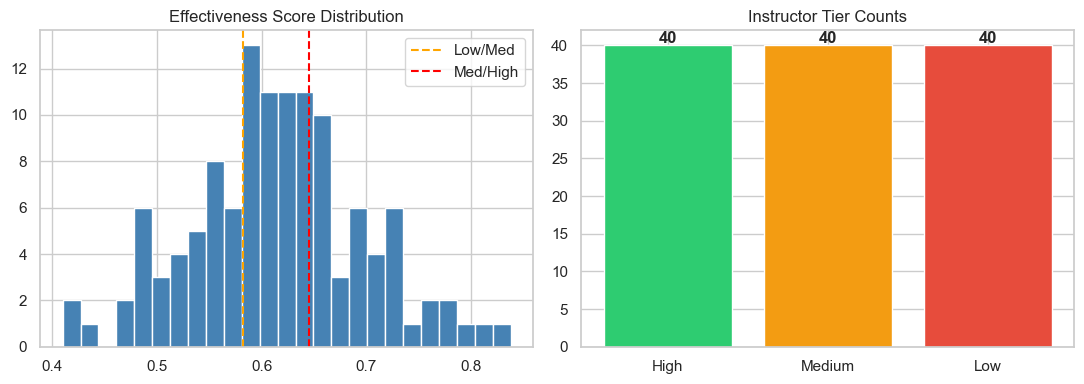

In [8]:
# Assign tiers via tertiles
t33, t67 = inst_df["effectiveness_mean"].quantile([0.333, 0.667])

def assign_tier(score):
    if score >= t67:
        return "High"
    elif score >= t33:
        return "Medium"
    else:
        return "Low"

inst_df["tier"] = inst_df["effectiveness_mean"].apply(assign_tier)

print(f"Thresholds: Low < {t33:.3f} <= Medium < {t67:.3f} <= High")
print(inst_df["tier"].value_counts())

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(inst_df["effectiveness_mean"], bins=25, color="steelblue", edgecolor="white")
axes[0].axvline(t33, color="orange", linestyle="--", label="Low/Med")
axes[0].axvline(t67, color="red",    linestyle="--", label="Med/High")
axes[0].set_title("Effectiveness Score Distribution")
axes[0].legend()

counts = inst_df["tier"].value_counts().reindex(["High", "Medium", "Low"])
axes[1].bar(counts.index, counts.values, color=["#2ecc71", "#f39c12", "#e74c3c"])
axes[1].set_title("Instructor Tier Counts")
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 0.3, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

---
## Step 4 — ML Model

We use a **Random Forest Classifier** as the primary model — it handles non-linear relationships well, provides feature importances, and does not require feature scaling.

A **Logistic Regression** baseline is included for comparison.

We train only on raw aggregated metrics, not the derived effectiveness score, to avoid label leakage.

In [9]:
feature_cols_model = [c for c in inst_df.columns
                      if c not in ["instructor_id", "tier", "effectiveness_mean"]]

X = inst_df[feature_cols_model]
y = inst_df["tier"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Logistic Regression baseline (needs scaling)
scaler = StandardScaler()
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(scaler.fit_transform(X_train), y_train)

# 5-fold cross-validation
rf_cv = cross_val_score(rf, X_train, y_train, cv=5, scoring="f1_macro")
lr_cv = cross_val_score(lr, scaler.transform(X_train), y_train, cv=5, scoring="f1_macro")

print(f"Random Forest CV F1-macro : {rf_cv.mean():.3f} +/- {rf_cv.std():.3f}")
print(f"Logistic Reg  CV F1-macro : {lr_cv.mean():.3f} +/- {lr_cv.std():.3f}")

Random Forest CV F1-macro : 0.902 +/- 0.041
Logistic Reg  CV F1-macro : 0.852 +/- 0.049


---
## Step 5 — Evaluate the Model

Classification Report (Test Set):
              precision    recall  f1-score   support

        High       0.78      0.88      0.82         8
         Low       0.89      1.00      0.94         8
      Medium       0.83      0.62      0.71         8

    accuracy                           0.83        24
   macro avg       0.83      0.83      0.83        24
weighted avg       0.83      0.83      0.83        24



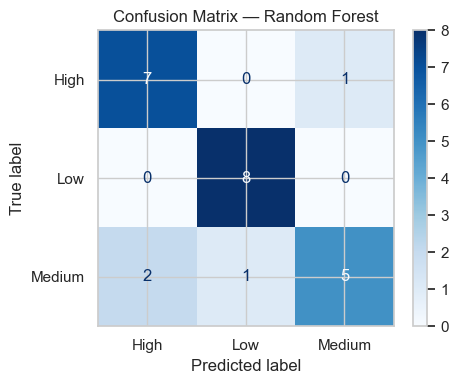

In [10]:
y_pred = rf.predict(X_test)

print("Classification Report (Test Set):")
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues")
ax.set_title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.show()

### Evaluation Notes

- We use **F1-macro** as the primary metric since it treats all tiers equally. Accuracy alone can be misleading.
- Tiers are tertile-based so classes are roughly balanced — class imbalance is not a major concern here.
- For flagging **low performers**, recall on the Low class matters most.
- For **recognising high performers**, precision on the High class matters more.

---
## Step 6 — Interpret Results

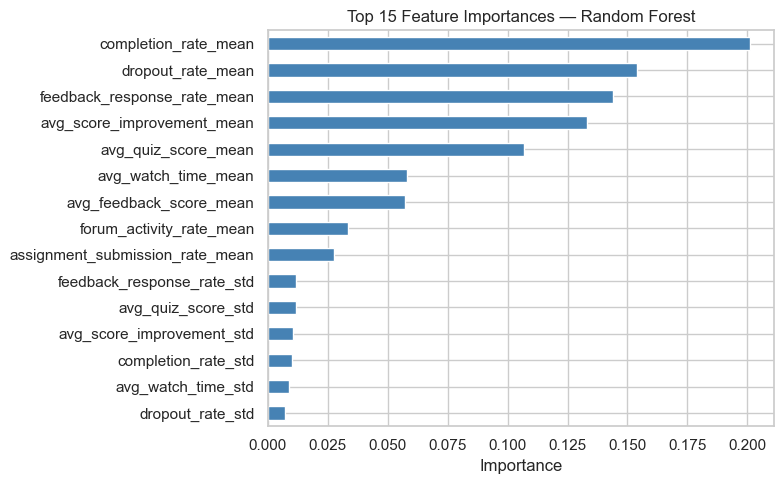

In [11]:
# Feature importances
importances = pd.Series(rf.feature_importances_, index=feature_cols_model)
top15 = importances.nlargest(15).sort_values()

plt.figure(figsize=(8, 5))
top15.plot(kind="barh", color="steelblue")
plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [12]:
# Average metrics per tier
tier_summary = inst_df.groupby("tier")[[
    "completion_rate_mean", "dropout_rate_mean",
    "avg_score_improvement_mean", "assignment_submission_rate_mean",
    "avg_feedback_score_mean"
]].mean().round(3).reindex(["High", "Medium", "Low"])

print("Average metrics per instructor tier:")
tier_summary

Average metrics per instructor tier:


,completion_rate_mean,dropout_rate_mean,avg_score_improvement_mean,assignment_submission_rate_mean,avg_feedback_score_mean
tier,,,,,
High,0.741,0.260,30.120,0.795,4.384
Medium,0.605,0.394,27.486,0.753,4.188
Low,0.462,0.530,23.637,0.707,4.043


### Key Findings

- `completion_rate_mean` and `assignment_submission_rate_mean` are the strongest predictors — they capture learner retention and active engagement.
- `avg_score_improvement_mean` is important because it directly measures learning gain.
- High-tier instructors consistently show higher completion, lower dropout, better score improvement, and higher assignment submission rates.

### Product Application
- Flag instructors whose completion rate drops below their own historical average mid-course.
- Pair Low-tier instructors with High-tier peers for mentoring.
- Prefer High-tier instructors for new or high-stakes course assignments.

---
## Mandatory Analysis Questions

### Q1. Which features most influenced instructor effectiveness, and why?

`completion_rate_mean` and `assignment_submission_rate_mean` were the strongest signals. Completion reflects whether learners stay through the full course — a direct result of instructor quality. Assignment submission shows that learners are actively engaged, which is partly driven by how instructors frame and motivate tasks. `avg_score_improvement_mean` also ranked highly because it directly measures learning gain.

---

### Q2. Which variables could be misleading or confounded?

- **avg_quiz_score** — easier courses will naturally have higher scores regardless of instructor quality.
- **avg_feedback_score** — popular or lenient instructors may get higher ratings. Also biased if only motivated learners submit feedback.
- **completion_rate** — short or easy courses inflate completion rates.
- **avg_score_improvement** — depends heavily on how weak learners were at the start.
- **forum_activity_rate** — influenced by platform design and course culture, not just the instructor.

---

### Q3. How could this model fail in real-world usage?

- **Label leakage:** The tier is derived from the same features used to train the model, so the model may be learning the formula rather than something generalizable.
- **Structural confounders:** A strong learner cohort makes any instructor look effective.
- **Gaming:** If instructors know they are scored on completion rate, they may reduce course difficulty to inflate it.
- **New instructors:** Instructors with very few batches have noisy aggregated features and unreliable predictions.
- **Temporal drift:** Averaging all historical batches hides whether an instructor is improving or declining.

---

### Q4. What additional data would improve this analysis?

- **Learner pre-assessment scores** — to measure true value-add rather than raw outcomes.
- **Course difficulty ratings** — to normalize quiz scores and completion rates across courses.
- **Batch timestamps** — to detect trends in instructor performance over time.
- **Learner demographics** — to control for prior education and motivation.

---

### Q5. Should this model be used for instructor performance evaluation? Why or why not?

Not as the sole or primary mechanism. It is useful for surfacing instructors for review, but should not drive high-stakes decisions like contract renewal on its own.

Many metrics are influenced by factors outside the instructor's control — course difficulty, learner background, platform design. Any deployment should combine model outputs with human judgment, and instructors should be informed about and able to contest their classifications.